In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/Pytorch-Models

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1aJsbt04Jz9xcLP_lg7fvP4Bpdce6GQlC/Pytorch-Models


In [2]:
!python --version

Python 3.11.13


In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("circuit/CircuitRecognitioncoco/train")
count_images("circuit/CircuitRecognitioncoco/valid")

Total images: 2652
Total images: 400


In [ ]:
# Check train annotations
with open("circuit/CircuitRecognitioncoco/train/_annotations.coco.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("circuit/CircuitRecognitioncoco/valid/_annotations.coco.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 2652
Train annotations: 14749
Categories: [{'id': 0, 'name': 'Predict-circuit-parameters', 'supercategory': 'none'}, {'id': 1, 'name': 'acv', 'supercategory': 'Predict-circuit-parameters'}, {'id': 2, 'name': 'c', 'supercategory': 'Predict-circuit-parameters'}, {'id': 3, 'name': 'i', 'supercategory': 'Predict-circuit-parameters'}, {'id': 4, 'name': 'l', 'supercategory': 'Predict-circuit-parameters'}, {'id': 5, 'name': 'r', 'supercategory': 'Predict-circuit-parameters'}, {'id': 6, 'name': 'v', 'supercategory': 'Predict-circuit-parameters'}]

Valid images: 400
Valid annotations: 2208


In [ ]:
# STEP 1: Install compatible PyTorch (2.0.1 + CUDA 11.7)
!pip install torch==2.0.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu117

# STEP 2: Install OpenMMLab tools
!pip install -U openmim
!mim install "mmengine>=0.7.4"
!mim install "mmcv==2.1.0"

# STEP 3: Clone MMDetection & install
!git clone https://github.com/open-mmlab/mmdetection.git
%cd mmdetection
!pip install -e .

In [2]:
# STEP 4: Final check
!python -c "import torch; import mmcv; import mmdet; print('PyTorch:', torch.__version__); print('MMCV:', mmcv.__version__); print('MMDet:', mmdet.__version__)"

PyTorch: 2.0.1+cu117
MMCV: 2.1.0
MMDet: 3.3.0


In [ ]:
!git clone https://github.com/open-mmlab/mmdeploy.git
%cd mmdeploy
!pip install -e .

In [2]:
!python -c "import mmdeploy; print('MMDeploy:', mmdeploy.__version__)"

MMDeploy: 1.3.1


In [ ]:
!pip install numpy==1.25.2 scipy==1.11.4

In [2]:
!ls mmdetection/configs/yolo/

metafile.yml
README.md
yolov3_d53_8xb8-320-273e_coco.py
yolov3_d53_8xb8-amp-ms-608-273e_coco.py
yolov3_d53_8xb8-ms-416-273e_coco.py
yolov3_d53_8xb8-ms-608-273e_coco.py
yolov3_mobilenetv2_8xb24-320-300e_coco.py
yolov3_mobilenetv2_8xb24-ms-416-300e_coco.py


In [3]:
custom_cfg = """
_base_ = 'yolov3_mobilenetv2_8xb24-320-300e_coco.py'

# Custom classes
dataset_type = 'CocoDataset'
metainfo = dict(classes=('Predict-circuit-parameters', 'acv', 'c', 'i', 'l', 'r', 'v'))
num_classes = 7

# Paths
data_root = '/content/gdrive/MyDrive/Pytorch-Models/circuit/'
train_ann = data_root + 'CircuitRecognitioncoco/train/_annotations.coco.json'
val_ann = data_root + 'CircuitRecognitioncoco/valid/_annotations.coco.json'
train_img = data_root + 'CircuitRecognitioncoco/train/'
val_img = data_root + 'CircuitRecognitioncoco/valid/'

# Pipelines
train_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=False),
    dict(type='Resize', scale=(320, 320), keep_ratio=False),
    dict(type='RandomFlip', prob=0.5),
    dict(type='Pad', size=(320, 320), pad_val=dict(img=(114, 114, 114))),
    dict(type='PackDetInputs')
]

test_pipeline = [
    dict(type='LoadImageFromFile'),
    dict(type='Resize', scale=(320, 320), keep_ratio=False),
    dict(type='Pad', size=(320, 320), pad_val=dict(img=(114, 114, 114))),
    dict(type='LoadAnnotations', with_bbox=True, with_mask=False),
    dict(type='PackDetInputs', meta_keys=('img_id', 'img_path', 'ori_shape', 'img_shape', 'scale_factor'))
]

# Data loader
train_dataloader = dict(
    batch_size=32,
    num_workers=2,
    dataset=dict(
        _delete_=True,
        type=dataset_type,
        data_root=data_root,
        ann_file=train_ann,
        data_prefix=dict(img=train_img),
        filter_cfg=dict(filter_empty_gt=True, min_size=32),
        pipeline=train_pipeline,
        metainfo=dict(classes=('Predict-circuit-parameters', 'acv', 'c', 'i', 'l', 'r', 'v')),
    )
)

val_dataloader = dict(
    batch_size=32,
    num_workers=2,
    dataset=dict(
        _delete_=True,
        type=dataset_type,
        data_root=data_root,
        ann_file=val_ann,
        data_prefix=dict(img=val_img),
        pipeline=test_pipeline,
        test_mode=True,
        metainfo=dict(classes=('Predict-circuit-parameters', 'acv', 'c', 'i', 'l', 'r', 'v')),
    )
)

test_dataloader = val_dataloader

# model settings
data_preprocessor = dict(
    type='DetDataPreprocessor',
    mean=[123.675, 116.28, 103.53],
    std=[58.395, 57.12, 57.375],
    bgr_to_rgb=True,
    pad_size_divisor=32)
model = dict(
    type='YOLOV3',
    data_preprocessor=data_preprocessor,
    backbone=dict(
        type='MobileNetV2',
        out_indices=(2, 4, 6),
        act_cfg=dict(type='LeakyReLU', negative_slope=0.1),
        init_cfg=dict(
            type='Pretrained', checkpoint='open-mmlab://mmdet/mobilenet_v2')),
    neck=dict(
        type='YOLOV3Neck',
        num_scales=3,
        in_channels=[320, 96, 32],
        out_channels=[96, 96, 96]),
    bbox_head=dict(
        type='YOLOV3Head',
        num_classes=num_classes,
        in_channels=[96, 96, 96],
        out_channels=[96, 96, 96],
        anchor_generator=dict(
            type='YOLOAnchorGenerator',
            base_sizes=[[(220, 125), (128, 222), (264, 266)],
                        [(35, 87), (102, 96), (60, 170)],
                        [(10, 15), (24, 36), (72, 42)]],
            strides=[32, 16, 8]),
        bbox_coder=dict(type='YOLOBBoxCoder'),
        featmap_strides=[32, 16, 8],
        loss_cls=dict(
            type='CrossEntropyLoss',
            use_sigmoid=True,
            loss_weight=1.0,
            reduction='sum'),
        loss_conf=dict(
            type='CrossEntropyLoss',
            use_sigmoid=True,
            loss_weight=1.0,
            reduction='sum'),
        loss_xy=dict(
            type='CrossEntropyLoss',
            use_sigmoid=True,
            loss_weight=2.0,
            reduction='sum'),
        loss_wh=dict(type='MSELoss', loss_weight=2.0, reduction='sum')),
    # training and testing settings
    train_cfg=dict(
        assigner=dict(
            type='GridAssigner',
            pos_iou_thr=0.5,
            neg_iou_thr=0.5,
            min_pos_iou=0)),
    test_cfg=dict(
        nms_pre=1000,
        min_bbox_size=0,
        score_thr=0.05,
        conf_thr=0.005,
        nms=dict(type='nms', iou_threshold=0.45),
        max_per_img=100))

# Evaluation: use mAP for detection
val_evaluator = dict(type='CocoMetric', ann_file=val_ann, metric=['bbox'], classwise=True)
test_evaluator = val_evaluator

# === Training
train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=5, val_interval=1)

val_cfg = dict(type='ValLoop')
test_cfg = dict(type='TestLoop')

# optimizer
optim_wrapper = dict(
    type='OptimWrapper',
    optimizer=dict(type='SGD', lr=0.003, momentum=0.9, weight_decay=0.0005),
    clip_grad=dict(max_norm=35, norm_type=2))

# learning rate
param_scheduler = [
    dict(type='LinearLR', start_factor=0.0001, by_epoch=False, begin=0, end=500),
    dict(
        type='MultiStepLR',
        begin=0,
        end=5,
        by_epoch=True,
        milestones=[3, 4],
        gamma=0.1)
]

# Logging and checkpointing
default_hooks = dict(
    logger=dict(type='LoggerHook', interval=1),
    checkpoint=dict(
        type='CheckpointHook',
        interval=1,
        save_best='coco/bbox_mAP',
        rule='greater'
    ),
)

# Output path
work_dir = '/content/gdrive/MyDrive/Pytorch-Models/mmdetection/mmdet_outputs/yolov3_circuit'

# Load pretrained COCO model
load_from = 'https://download.openmmlab.com/mmdetection/v2.0/yolo/yolov3_mobilenetv2_320_300e_coco/yolov3_mobilenetv2_320_300e_coco_20210719_215349-d18dff72.pth'
"""

with open('mmdetection/configs/yolo/yolov3_circuit.py', 'w') as f:
    f.write(custom_cfg)

In [4]:
!python mmdetection/tools/train.py \
  mmdetection/configs/yolo/yolov3_circuit.py --amp

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
02/27 09:02:13 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 519884107
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA R

In [5]:
!python mmdetection/tools/test.py mmdetection/configs/yolo/yolov3_circuit.py mmdetection/mmdet_outputs/yolov3_circuit/best_coco_bbox_mAP_epoch_5.pth

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
02/27 09:34:16 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1070381457
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu117
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 201511 (a.k.a. OpenMP 4.5)
  - LAPACK is enabled (usually provided by MKL)
  - NNPACK is enabled
  - CPU capability usage: AVX2
  - CUDA 

In [6]:
from mmdet.apis import init_detector, inference_detector
import mmcv

# Config and checkpoint paths
config_file = 'mmdetection/configs/yolo/yolov3_circuit.py'
checkpoint_file = 'mmdetection/mmdet_outputs/yolov3_circuit/best_coco_bbox_mAP_epoch_5.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

# Image path
img = 'circuit/CircuitRecognitioncoco/valid/autockt_-83_png.rf.528f173e9fc24d0099f7645860356c33.jpg'

# Run inference
result = inference_detector(model, img)
print(result)

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117


Loads checkpoint by local backend from path: mmdetection/mmdet_outputs/yolov3_circuit/best_coco_bbox_mAP_epoch_5.pth
<DetDataSample(

    META INFORMATION
    img_path: 'circuit/CircuitRecognitioncoco/valid/autockt_-83_png.rf.528f173e9fc24d0099f7645860356c33.jpg'
    img_shape: (320, 320)
    batch_input_shape: (320, 320)
    ori_shape: (528, 528)
    img_id: 0
    pad_shape: (320, 320)
    scale_factor: (0.6060606060606061, 0.6060606060606061)

    DATA FIELDS
    ignored_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            labels: tensor([], device='cuda:0', dtype=torch.int64)
            bboxes: tensor([], device='cuda:0', size=(0, 4))
        ) at 0x7a74d8e59710>
    gt_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            labels: tensor([], device='cuda:0', dtype=torch.int64)
            bboxes: tensor([], device='cuda:0', size=(0, 4))
        ) at 0x7a74d8e59510>
    pre

Loads checkpoint by local backend from path: mmdetection/mmdet_outputs/yolov3_circuit/best_coco_bbox_mAP_epoch_5.pth


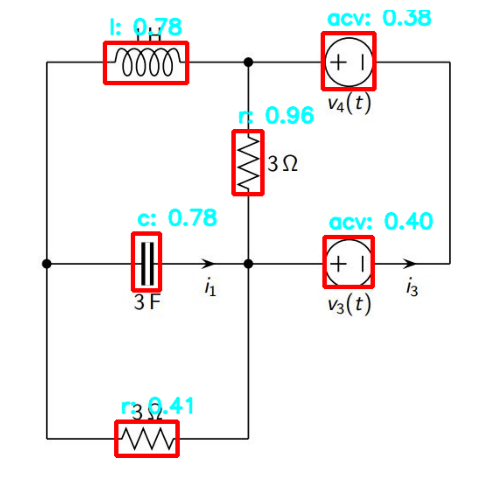

In [7]:
from mmdet.apis import init_detector, inference_detector
import mmcv
import cv2
import matplotlib.pyplot as plt
import torch

CLASS_LABELS = ['', 'acv', 'c', 'i', 'l', 'r', 'v']

# Config and checkpoint paths
config_file = 'mmdetection/configs/yolo/yolov3_circuit.py'
checkpoint_file = 'mmdetection/mmdet_outputs/yolov3_circuit/best_coco_bbox_mAP_epoch_5.pth'

# Initialize the model
model = init_detector(config_file, checkpoint_file, device='cuda:0')  # or 'cpu'

def draw_bbox_with_label(img, bbox, label, score, color=(0, 0, 255), thickness=3):
    xmin, ymin, xmax, ymax = map(int, bbox)
    # Draw rectangle
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, thickness)
    # Put label text
    text = f"{label}: {score:.2f}"
    cv2.putText(
        img, text, (xmin + 5, ymin - 10),
        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2, cv2.LINE_AA
    )

# Image path
img_path = 'circuit/CircuitRecognitioncoco/valid/autockt_-83_png.rf.528f173e9fc24d0099f7645860356c33.jpg'
img = cv2.imread(img_path)
if img is None:
    raise Exception("Image not found or unreadable")

# Run inference
results = inference_detector(model, img_path)

# Access the prediction results from the DetDataSample object
pred_instances = results.pred_instances

CONF_THRESHOLD = 0.3
img_with_bbox = img.copy()

# Draw boxes and labels
# pred_instances.bboxes, pred_instances.scores, and pred_instances.labels are tensors
for i in range(len(pred_instances.bboxes)):
    score = pred_instances.scores[i]
    if score < CONF_THRESHOLD:
        continue
    bbox = pred_instances.bboxes[i].tolist() # Convert tensor to list for drawing
    label_id = pred_instances.labels[i].item() # Get integer label ID from tensor
    class_name = CLASS_LABELS[label_id] # Use label_id directly as index since classes are 0-indexed

    draw_bbox_with_label(img_with_bbox, bbox, class_name, score)

# Show result
img_with_bbox_rgb = cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.axis('off')
plt.imshow(img_with_bbox_rgb)
plt.show()

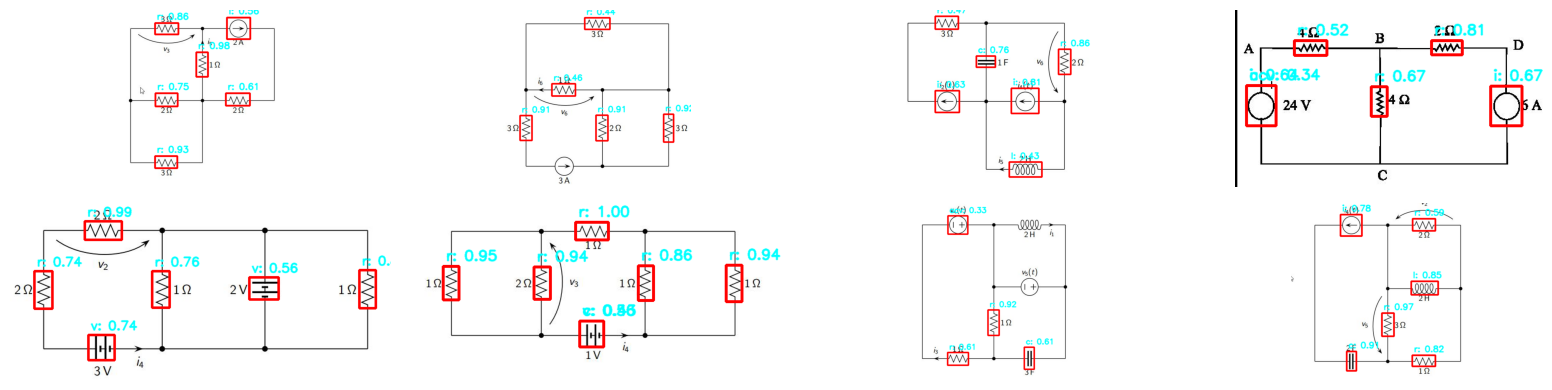

In [8]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "circuit/CircuitRecognitioncoco/valid/"

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)

    results = inference_detector(model, image)

    # Access the prediction results from the DetDataSample object
    pred_instances = results.pred_instances

    CONF_THRESHOLD = 0.3
    img_with_bbox = img.copy()

    # Draw boxes and labels
    # pred_instances.bboxes, pred_instances.scores, and pred_instances.labels are tensors
    for i in range(len(pred_instances.bboxes)):
        score = pred_instances.scores[i]
        if score < CONF_THRESHOLD:
            continue
        bbox = pred_instances.bboxes[i].tolist() # Convert tensor to list for drawing
        label_id = pred_instances.labels[i].item() # Get integer label ID from tensor
        class_name = CLASS_LABELS[label_id] # Use label_id directly as index since classes are 0-indexed

        draw_bbox_with_label(img_with_bbox, bbox, class_name, score)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 100.3 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.25.2 which is incompatible.
tensorflow 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 3.20.2 which is incompatible.


In [10]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.6/252.6 MB 8.1 MB/s eta 0:00:00


In [11]:
!python mmdeploy/tools/deploy.py \
    mmdeploy/configs/mmdet/detection/detection_onnxruntime_static.py \
    mmdetection/configs/yolo/yolov3_circuit.py \
    mmdetection/mmdet_outputs/yolov3_circuit/best_coco_bbox_mAP_epoch_5.pth \
    circuit/CircuitRecognitioncoco/valid/autockt_-83_png.rf.528f173e9fc24d0099f7645860356c33.jpg \
    --work-dir mmdeploy/mmdeploy_output/yolov3_circuit/ \
    --device cpu \
    --dump-info

Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
02/27 09:43:51 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "Codebases" registry tree. As a workaround, the current "Codebases" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
02/27 09:43:51 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "mmdet_tasks" registry tree. As a workaround, the current "mmdet_tasks" registry in "mmdeploy" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.
Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1+cu117
02/27 09:43:56 - mmengine - INFO - Start pipe

In [12]:
%ls mmdeploy/mmdeploy_output/yolov3_circuit/

deploy.json  end2end.onnx            output_pytorch.jpg
detail.json  output_onnxruntime.jpg  pipeline.json


In [14]:
import onnxruntime
import numpy as np
import cv2
import torch

# Load image and preprocess
img_path = "circuit/CircuitRecognitioncoco/valid/autockt_-83_png.rf.528f173e9fc24d0099f7645860356c33.jpg"

mean = np.array([123.675, 116.28, 103.53], dtype=np.float32)
std = np.array([58.395, 57.12, 57.375], dtype=np.float32)

img = cv2.imread(img_path)
img_resized = cv2.resize(img, (320, 320))
img_input = (img_resized[:, :, ::-1].astype(np.float32) - mean) / std
img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

# Run inference
session = onnxruntime.InferenceSession("mmdeploy/mmdeploy_output/yolov3_circuit/end2end.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name
outputs = session.run(None, {input_name: img_input})

# outputs is a list, often like [boxes, scores, keypoints]
print("Output:", [o.shape for o in outputs])

Output: [(1, 100, 5), (1, 100)]


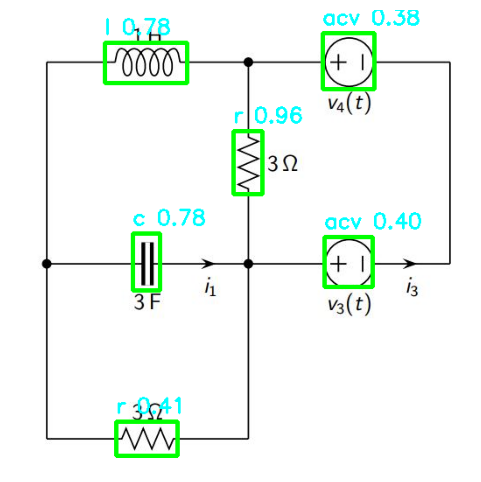

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

CLASS_LABELS = ['', 'acv', 'c', 'i', 'l', 'r', 'v']

# 1. Get original dimensions
orig_h, orig_w = img.shape[:2]
img_with_bbox = img.copy()

# 2. Extract boxes and labels
boxes_with_scores = outputs[0][0] # Shape (200, 5)
labels = outputs[1][0]            # Shape (200,)

# 3. Filter by threshold (e.g., 0.5)
score_thr = 0.3
keep_idx = boxes_with_scores[:, 4] > score_thr
valid_boxes = boxes_with_scores[keep_idx]
valid_labels = labels[keep_idx]

# 4. Scale and Draw
for i in range(len(valid_boxes)):
    box = valid_boxes[i, :4]
    score = valid_boxes[i, 4]
    label = int(valid_labels[i])
    labeltext = CLASS_LABELS[label]

    # Calculate scale factors
    x1 = int(box[0] * orig_w / 320)
    y1 = int(box[1] * orig_h / 320)
    x2 = int(box[2] * orig_w / 320)
    y2 = int(box[3] * orig_h / 320)

    # Draw on the ORIGINAL image
    cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(img_with_bbox, f"{labeltext} {score:.2f}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

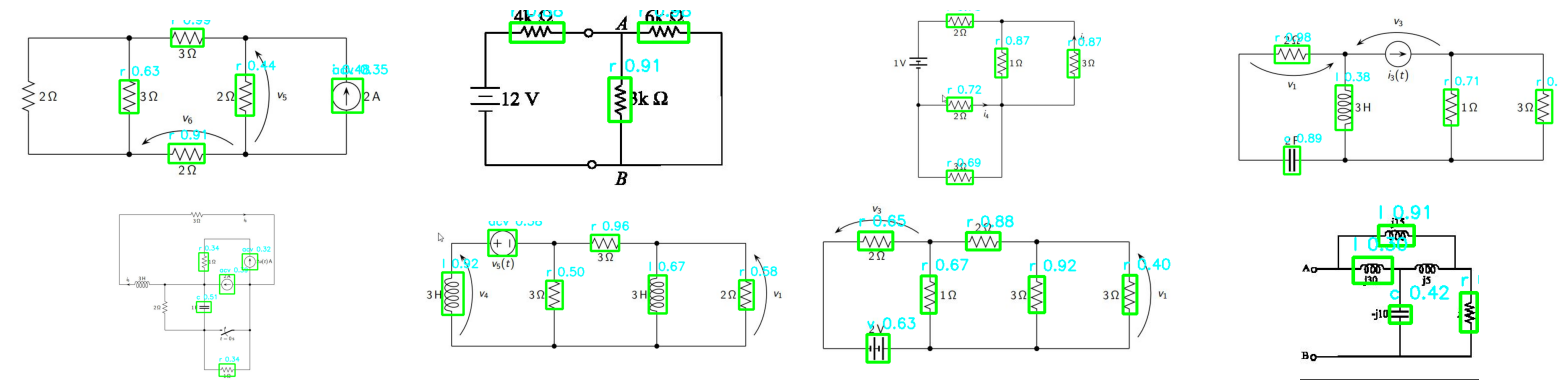

In [19]:
import numpy as np
import os
import random
# ---------------- CONFIG ----------------
val_dir = "circuit/CircuitRecognitioncoco/valid/"

CLASS_LABELS = ['', 'acv', 'c', 'i', 'l', 'r', 'v']

session = onnxruntime.InferenceSession("mmdeploy/mmdeploy_output/yolov3_circuit/end2end.onnx", providers=["CUDAExecutionProvider"])
input_name = session.get_inputs()[0].name

# visualization layout
N = 8
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(2, 4, ii+1)

    img = cv2.imread(image)
    img_resized = cv2.resize(img, (320, 320))
    img_input = (img_resized[:, :, ::-1].astype(np.float32) - mean) / std
    img_input = img_input.transpose(2, 0, 1)[np.newaxis, :]  # (1, 3, H, W)

    outputs = session.run(None, {input_name: img_input})

    orig_h, orig_w = img.shape[:2]
    img_with_bbox = img.copy()

    # 2. Extract boxes and labels
    boxes_with_scores = outputs[0][0] # Shape (200, 5)
    labels = outputs[1][0]            # Shape (200,)

    # 3. Filter by threshold (e.g., 0.5)
    score_thr = 0.3
    keep_idx = boxes_with_scores[:, 4] > score_thr
    valid_boxes = boxes_with_scores[keep_idx]
    valid_labels = labels[keep_idx]

    # 4. Scale and Draw
    for i in range(len(valid_boxes)):
        box = valid_boxes[i, :4]
        score = valid_boxes[i, 4]
        label = int(valid_labels[i])
        labeltext = CLASS_LABELS[label]

        # Calculate scale factors
        x1 = int(box[0] * orig_w / 320)
        y1 = int(box[1] * orig_h / 320)
        x2 = int(box[2] * orig_w / 320)
        y2 = int(box[3] * orig_h / 320)

        # Draw on the ORIGINAL image
        cv2.rectangle(img_with_bbox, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(img_with_bbox, f"{labeltext} {score:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 0), 2)

    plt.subplot(rows, cols, ii + 1)
    plt.imshow(cv2.cvtColor(img_with_bbox, cv2.COLOR_BGR2RGB))
    plt.axis("off")

plt.tight_layout()
plt.show()